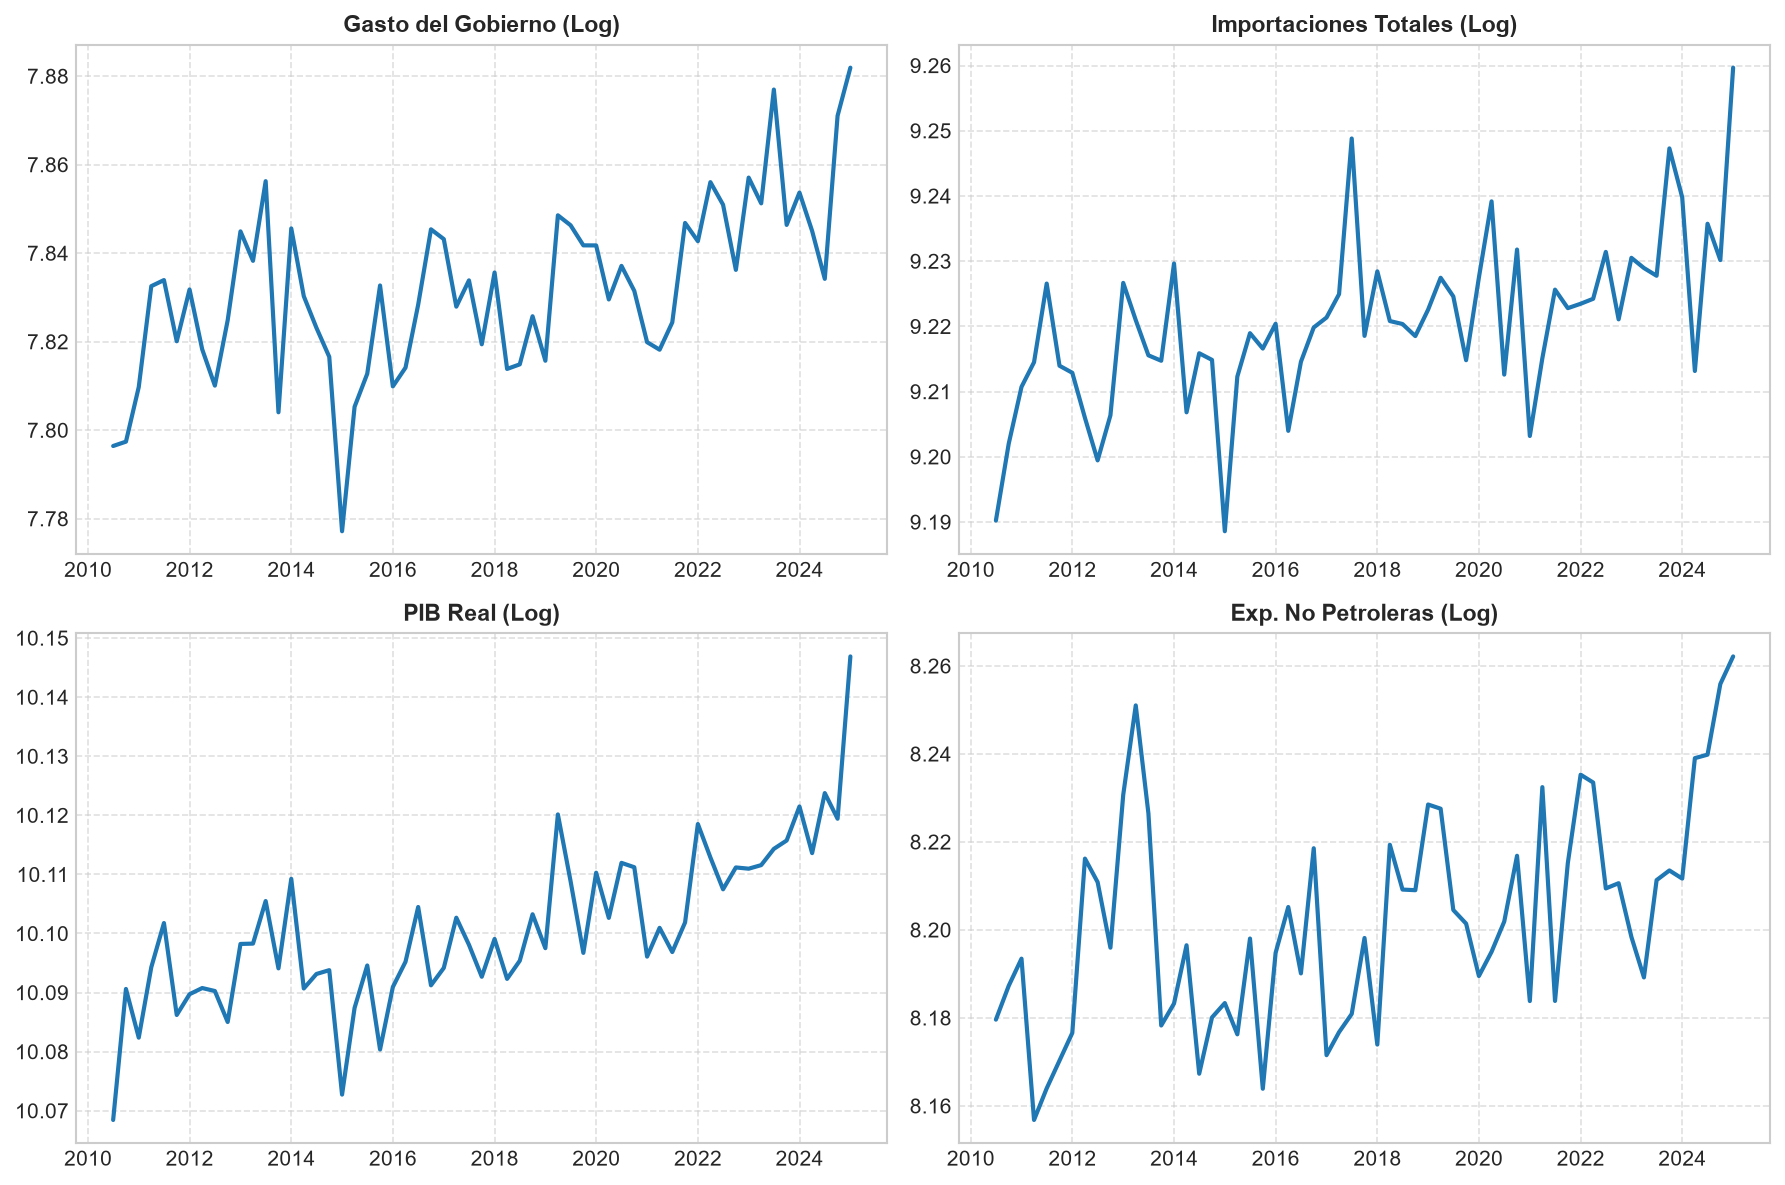

C:\Users\E L I  T E B O O K\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


TypeError: BaseIRAnalysis.plot() got an unexpected keyword argument 'ortho'. Did you mean 'orth'?

In [1]:
# Cell 1: Importación de librerías y configuración de gráficos
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen

# Configuración estética para gráficos del paper/dashboard
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 150

# Cell 2: Cargar datos procesados
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(
    BASE_DIR / "data" / "processed" / "series_macro_ecuador.csv",
    index_col=0,
    parse_dates=True,
)

var_cols = [
    "log_gasto_gobierno",
    "log_importaciones",
    "log_pib_real",
    "log_exportaciones_no_pet",
]
df_var = df[var_cols]

# Cell 3: Gráfico de Series de Tiempo en Niveles vs Diferencias
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

nombres_titulos = [
    "Gasto del Gobierno (Log)",
    "Importaciones Totales (Log)",
    "PIB Real (Log)",
    "Exp. No Petroleras (Log)",
]

for i, col in enumerate(var_cols):
    axes[i].plot(df_var.index, df_var[col], color="#1f77b4", linewidth=2)
    axes[i].set_title(nombres_titulos[i], fontsize=11, fontweight="bold")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(
    BASE_DIR / "outputs" / "figures" / "series_niveles.png", bbox_inches="tight"
)
plt.show()

# Cell 4: Estimación del Modelo VECM y Funciones Impulso-Respuesta (IRF)
# Usando k_ar_diff=1 y coint_rank=1
vecm_model = VECM(df_var, k_ar_diff=1, coint_rank=1, deterministic="co")
vecm_fit = vecm_model.fit()

# Generar IRF a 10 periodos (trimestres)
irf = vecm_fit.irf(periods=10)

# Graficar respuesta de Importaciones ante un choque en el Gasto del Gobierno
fig_irf = irf.plot(
    impulse="log_gasto_gobierno", response="log_importaciones", ortho=True
)
plt.suptitle(
    "Respuesta de las Importaciones ante un Shock en el Gasto Público", y=1.02
)
plt.savefig(
    BASE_DIR / "outputs" / "figures" / "irf_gasto_importaciones.png",
    bbox_inches="tight",
)
plt.show()